In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm
import scipy.interpolate as interp
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def game(N, p, player):                                         #N number of doors, p number of opened doors, player strategy

    doors = np.zeros((N,2))                                     #all doors are losing and not chosen [0, 0]
    car = random.randint(0, N-1)
    doors[car][0] = 1                                           #1 door is winning and not chosen [1, 0]
    choice = random.randint(0, N-1)
    doors[choice][1] = 1                                        #1 door is losing/winning and chosen [x, 1]

    if car == choice:                                           #move the winning door to second last and the chosen door to last
        doors = np.delete(doors, car, 0)
        doors = np.append(doors, [[1, 1]], 0)                   #winning and chosen
    else:
        doors = np.delete(doors, [car, choice], 0)
        doors = np.append(doors, ([1, 0],[0, 1]), 0)            #winning and not chosen + losing and chosen

    doors = np.delete(doors, [x for x in range(p)], 0)          #because now it's easy to open the other doors

    if player == "keeper":
        if car == choice: return 1
        else: return 0

    if player == "switcher":
        doors = np.delete(doors, np.where(doors[:,1] == 1), 0)  #notice that now the winning door is always last (if it still exists)
        second_choice = random.randint(0, len(doors)-1)
        #doors[second_choice][1] = 1                             #useless but to clarify that now this door is losing/winning and chosen
        if doors[second_choice][0] == 1: return 1
        else: return 0

    if player == "random":
        random_choice = random.randint(0, len(doors)-1)
        #doors[second_choice][1] = 1                             #useless but to clarify that now this door is losing/winning and chosen
        if doors[random_choice][0] == 1: return 1
        else: return 0


In [3]:
N = 10
p = 8
tries = 100000
switcher_wins = 0
keeper_wins = 0
random_wins = 0
for i in tqdm(range(tries)):
    switcher_wins = switcher_wins + game(N, p, "switcher")
    keeper_wins = keeper_wins + game(N, p, "keeper")
    random_wins = random_wins + game(N, p, "random")

  0%|          | 0/100000 [00:00<?, ?it/s]

In [4]:
print(switcher_wins/tries)
print(keeper_wins/tries)
print(random_wins/tries)

0.89992
0.0999
0.49841


In [5]:
N = 10                          #number of doors

x = []      #number of doors
y = []      #number of opened_doors
z = []      #ratio between switcher and keeper
a = []      #keeper winrate
b = []      #switcher winrate

tries = 10000

for i in tqdm(range(3, N+1)):
    if N < 3: continue
    p = i-2
    for j in range(1, p+1):
        x.append(i)
        y.append(j)
        switcher_score = 0
        keeper_score = 0
        for k in range(tries):
            switcher_score = switcher_score + game(i, j, "switcher")
            keeper_score = keeper_score + game(i, j, "keeper")

        ratio = float(keeper_score/switcher_score)
        z.append(ratio)
        a.append(float(keeper_score/tries))
        b.append(float(switcher_score/tries))

  0%|          | 0/8 [00:00<?, ?it/s]

In [6]:
print(x)
print(y)
print(z)
print(a)
print(b)

[3, 4, 4, 5, 5, 5, 6, 6, 6, 6, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10]
[1, 1, 2, 1, 2, 3, 1, 2, 3, 4, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 6, 7, 1, 2, 3, 4, 5, 6, 7, 8]
[0.5022542831379622, 0.6646453994199841, 0.33760683760683763, 0.7681214421252371, 0.5043914680050188, 0.24517974872496578, 0.7728557964184731, 0.5973561986423723, 0.40062484979572216, 0.19682880305197903, 0.8558823529411764, 0.6918269230769231, 0.49339521599428776, 0.3232827023350714, 0.1714820446835887, 0.8684931506849315, 0.7396862289366647, 0.5293072824156305, 0.4331344331344331, 0.28218495013599276, 0.15202279202279204, 0.8505311077389985, 0.8123324396782842, 0.6324175824175824, 0.522969837587007, 0.3686131386861314, 0.2535083748302399, 0.12547656425207446, 0.9022140221402214, 0.8232445520581114, 0.6698762035763411, 0.5367847411444142, 0.4382716049382716, 0.31078851864071266, 0.22118794326241134, 0.11159614954107902]
[0.3342, 0.2521, 0.2528, 0.2024, 0.201, 0.1

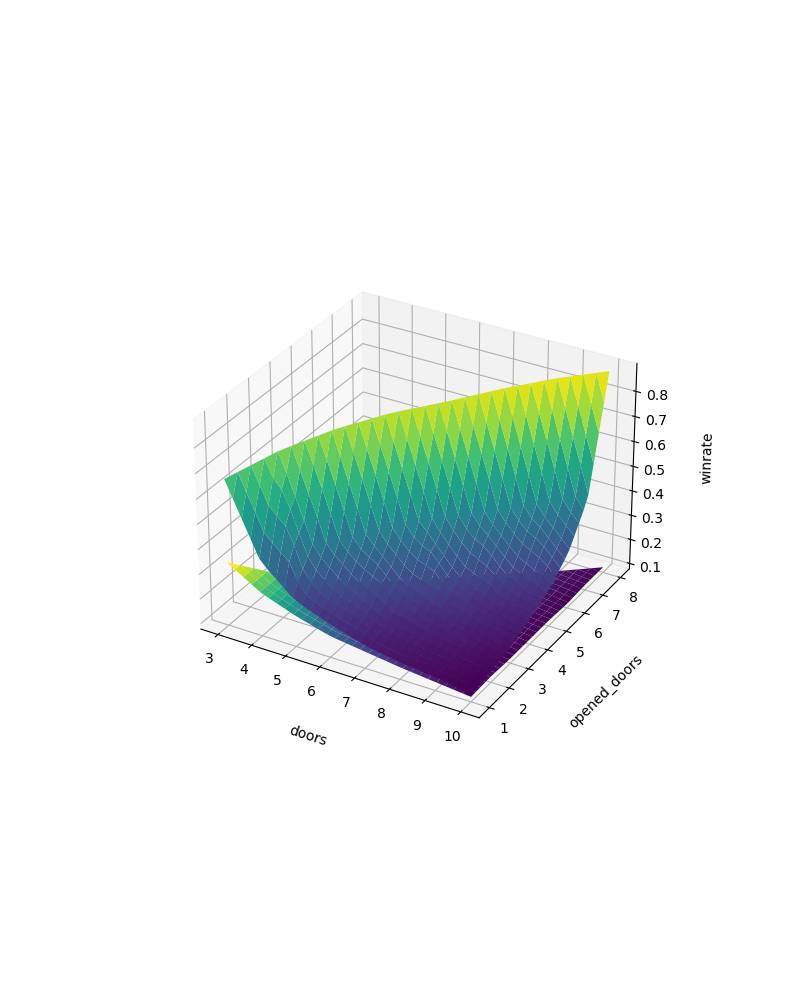

In [ ]:
%matplotlib widget

plotx,ploty = np.meshgrid(np.linspace(np.min(x),np.max(x),30),np.linspace(np.min(y),np.max(y),30))
#plotz = interp.griddata((x,y), z, (plotx,ploty),method='linear')
plota = interp.griddata((x,y), a, (plotx,ploty), method='linear')
plotb = interp.griddata((x,y), b, (plotx,ploty), method='linear')

fig = plt.figure(figsize = (8,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(plotx, ploty, plota, cstride=1, rstride=1, cmap='viridis')
ax.plot_surface(plotx, ploty, plotb, cstride=1, rstride=1, cmap='viridis')
#ax.plot_surface(plotx, ploty, plotz, cstride=1, rstride=1, cmap='viridis')
ax.set_xlabel('doors', labelpad=20)
ax.set_ylabel('opened_doors', labelpad=20)
ax.set_zlabel('winrate', labelpad=20)
ax.set_box_aspect(aspect=None, zoom=0.8)
plt.show()